# EEGNet Performance Dashboard

This notebook loads training artifacts (`results.csv` and run log) and shows:
- Summary metrics table
- Metric bar chart
- Training curves (loss/F1 over epochs) parsed from log

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# Change this to any run name you want to inspect.
RUN_NAME = "eegnet_100sub_100ep_lr3e3"
ROOT = Path("/mount/NAS-workspace-portal/eeg2025-Vistec")

RESULTS_CSV = ROOT / "jobs" / RUN_NAME / "results.csv"
LOG_FILE = ROOT / "jobs" / "logs" / "eegnet_100x100.log"

print(f"Results CSV: {RESULTS_CSV}")
print(f"Log file:    {LOG_FILE}")
print(f"CSV exists:  {RESULTS_CSV.exists()}")
print(f"Log exists:  {LOG_FILE.exists()}")

Results CSV: /mount/NAS-workspace-portal/eeg2025-Vistec/jobs/eegnet_100sub_100ep_lr3e3/results.csv
Log file:    /mount/NAS-workspace-portal/eeg2025-Vistec/jobs/logs/eegnet_100x100.log
CSV exists:  True
Log exists:  True


Latest metrics row:


,testing_loss,accuracy,sensitivity,specificity,f1-score-binary,f1-score-macro,f1-score-weighted,balanced_accuracy_score,roc_auc_score,cohen_kappa_score
0,0.65653,0.692558,0.964567,0.030351,0.81644,0.435402,0.594552,0.497459,0.562803,-0.00687


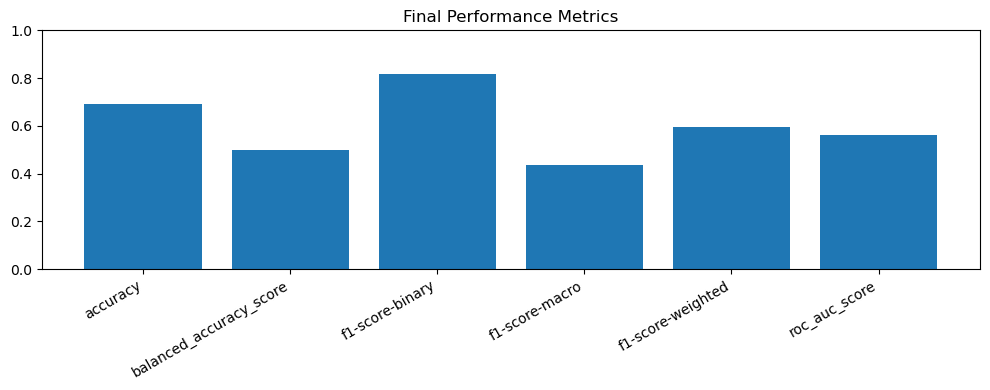

In [2]:
# 1) Final metrics table from results.csv
if not RESULTS_CSV.exists():
    print("results.csv not found yet. Wait for training to finish.")
else:
    results_df = pd.read_csv(RESULTS_CSV)
    print("Latest metrics row:")
    display(results_df.tail(1))

    if not results_df.empty:
        latest = results_df.iloc[-1]
        metrics_to_plot = [
            "accuracy",
            "balanced_accuracy_score",
            "f1-score-binary",
            "f1-score-macro",
            "f1-score-weighted",
            "roc_auc_score",
        ]
        metrics_to_plot = [m for m in metrics_to_plot if m in results_df.columns]

        plot_df = latest[metrics_to_plot].astype(float).reset_index()
        plot_df.columns = ["metric", "value"]

        plt.figure(figsize=(10, 4))
        plt.bar(plot_df["metric"], plot_df["value"])
        plt.ylim(0, 1)
        plt.xticks(rotation=30, ha="right")
        plt.title("Final Performance Metrics")
        plt.tight_layout()
        plt.show()

Parsed 100 epochs from log.


,epoch,epochs_total,train_loss,train_f1,val_loss,val_f1
90,91,100,0.6167,0.7904,0.6159,0.7979
91,92,100,0.6122,0.7927,0.6161,0.7982
92,93,100,0.6132,0.7886,0.6171,0.7973
93,94,100,0.6125,0.7918,0.6182,0.7976
94,95,100,0.6161,0.7882,0.6174,0.7978
95,96,100,0.6167,0.7928,0.6176,0.7976
96,97,100,0.6132,0.7894,0.6189,0.7968
97,98,100,0.6159,0.7904,0.6184,0.7969
98,99,100,0.6193,0.7856,0.6176,0.7972
99,100,100,0.6166,0.7870,0.6166,0.7972


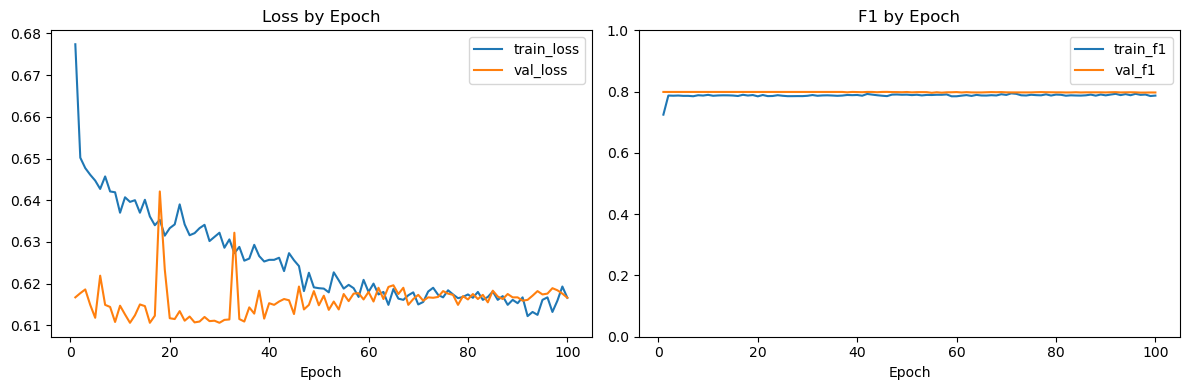

In [3]:
# 2) Training curves from log file (works while run is still ongoing)
if not LOG_FILE.exists():
    print("log file not found")
else:
    text = LOG_FILE.read_text(encoding="utf-8", errors="ignore")

    pattern = re.compile(
        r"Epoch:\s*(\d+)/(\d+),\s*"
        r"Train Loss:\s*([0-9.]+),\s*Train F1:\s*([0-9.]+),\s*"
        r"Val Loss:\s*([0-9.]+),\s*Val F1:\s*([0-9.]+)",
        flags=re.MULTILINE,
    )
    rows = [
        {
            "epoch": int(m.group(1)),
            "epochs_total": int(m.group(2)),
            "train_loss": float(m.group(3)),
            "train_f1": float(m.group(4)),
            "val_loss": float(m.group(5)),
            "val_f1": float(m.group(6)),
        }
        for m in pattern.finditer(text)
    ]

    curves_df = pd.DataFrame(rows)
    if curves_df.empty:
        print("No epoch lines parsed yet.")
    else:
        print(f"Parsed {len(curves_df)} epochs from log.")
        display(curves_df.tail(10))

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(curves_df["epoch"], curves_df["train_loss"], label="train_loss")
        axes[0].plot(curves_df["epoch"], curves_df["val_loss"], label="val_loss")
        axes[0].set_title("Loss by Epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()

        axes[1].plot(curves_df["epoch"], curves_df["train_f1"], label="train_f1")
        axes[1].plot(curves_df["epoch"], curves_df["val_f1"], label="val_f1")
        axes[1].set_title("F1 by Epoch")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylim(0, 1)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

=== Remaining Subjects Evaluation Set ===
X500 shape: (38850, 1, 13, 201)
X100 shape: (8623, 1, 13, 201)
Known subjects (n100): 100
Remaining unique subjects: 400
Remaining samples: 30227

=== Checkpoint n=10 ===
Accuracy=0.4000, BAcc=0.5000, AUC=0.3750


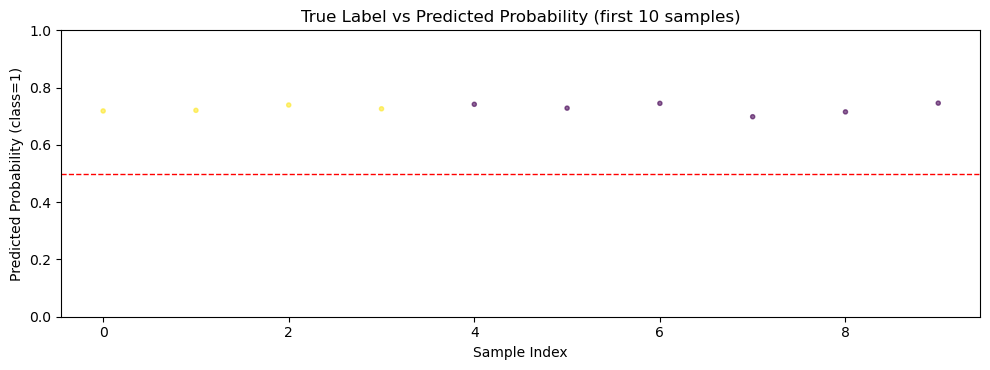


=== Checkpoint n=50 ===
Accuracy=0.4200, BAcc=0.5000, AUC=0.5205


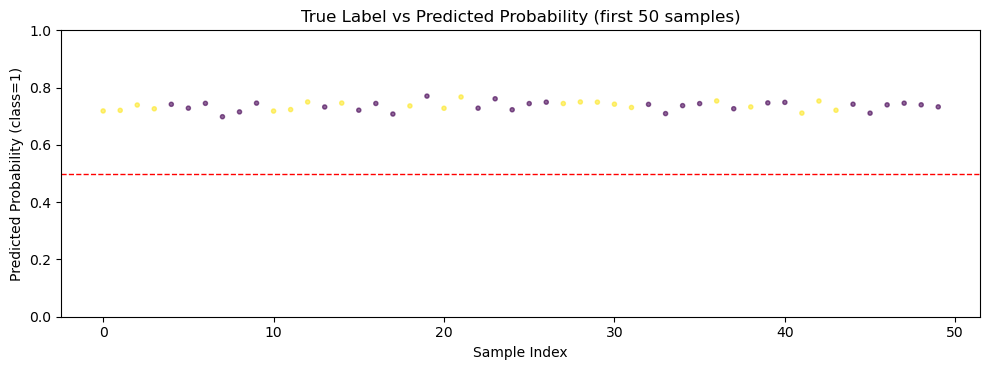


=== Checkpoint n=100 ===
Accuracy=0.6100, BAcc=0.5000, AUC=0.4876


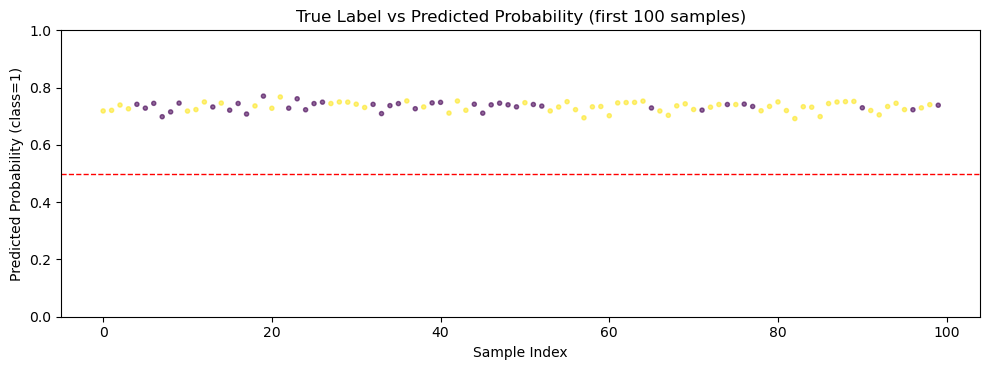


=== Checkpoint n=200 ===
Accuracy=0.6500, BAcc=0.5000, AUC=0.4502


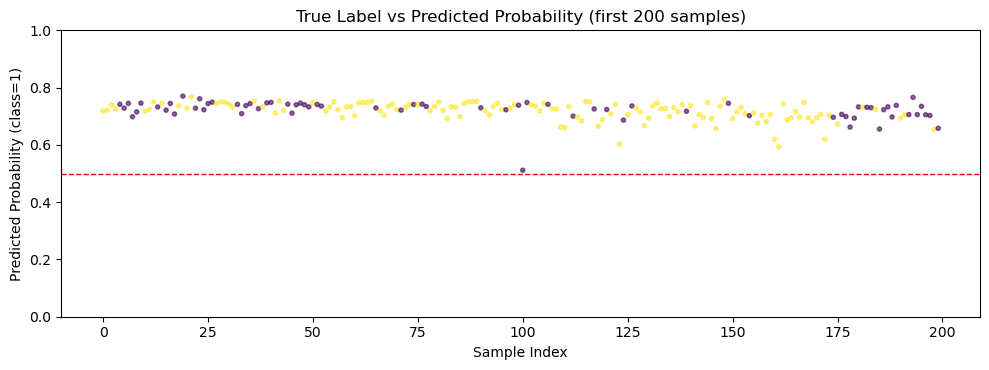


=== Checkpoint n=500 ===
Accuracy=0.7040, BAcc=0.5034, AUC=0.4796


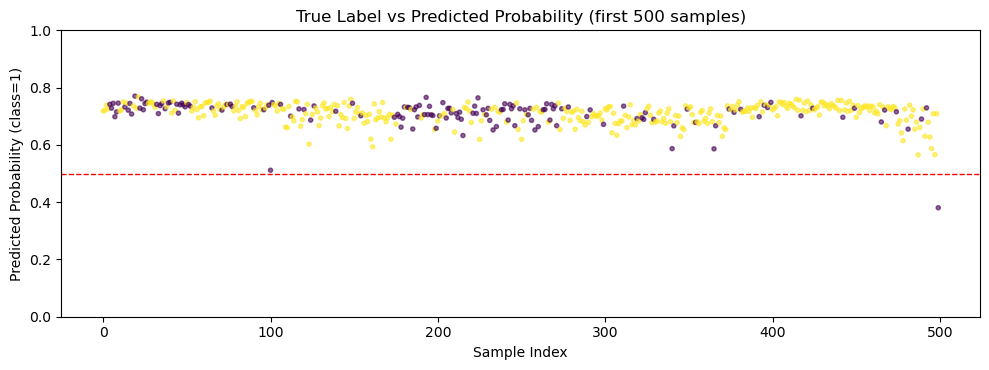


=== Checkpoint n=1000 ===
Accuracy=0.6220, BAcc=0.4976, AUC=0.5816


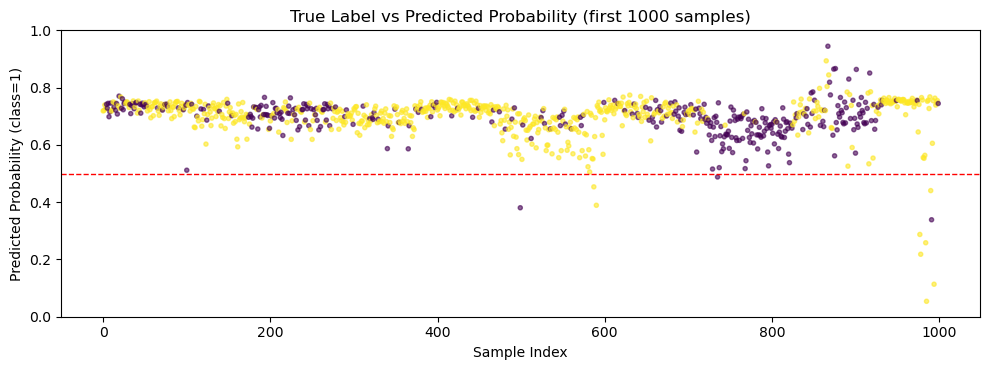


=== Checkpoint n=2000 ===
Accuracy=0.6260, BAcc=0.4983, AUC=0.5774


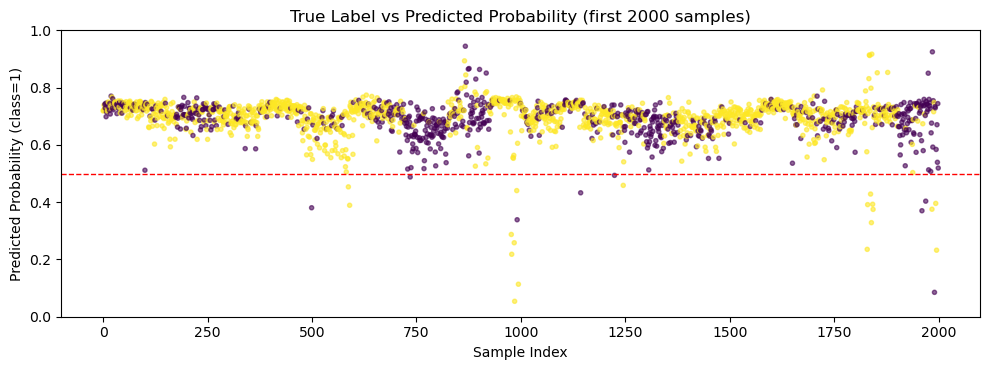


=== Checkpoint n=3000 ===
Accuracy=0.6677, BAcc=0.5020, AUC=0.5959


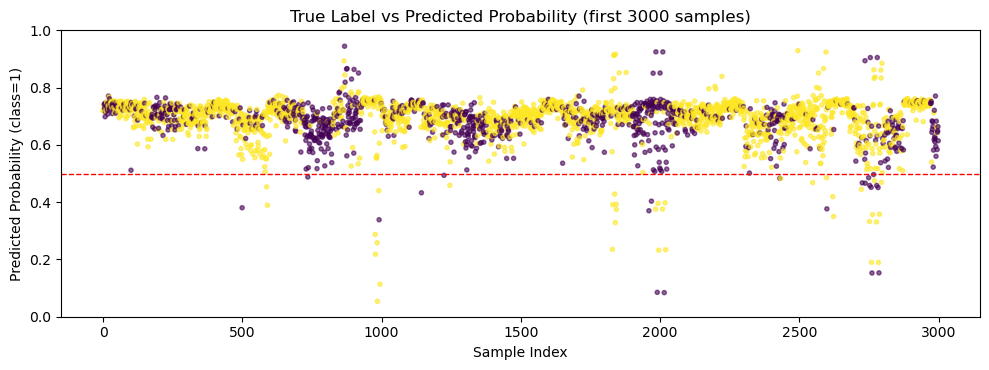


=== Checkpoint n=4000 ===
Accuracy=0.6570, BAcc=0.5004, AUC=0.5690


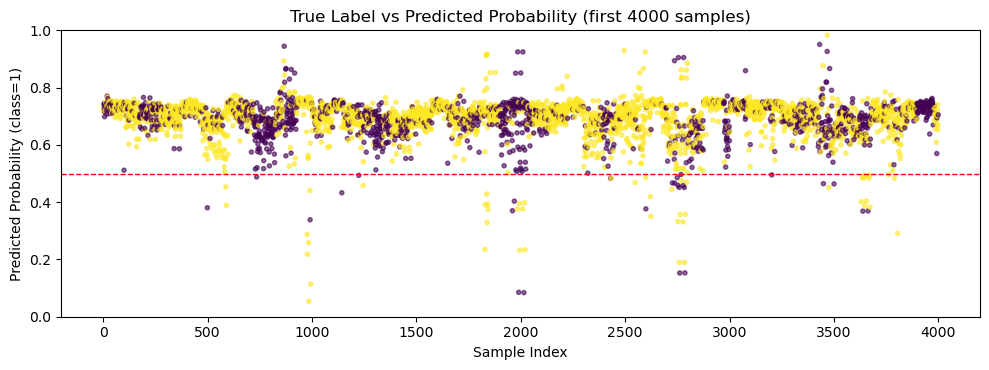


=== Checkpoint n=5000 ===
Accuracy=0.6700, BAcc=0.5041, AUC=0.5771


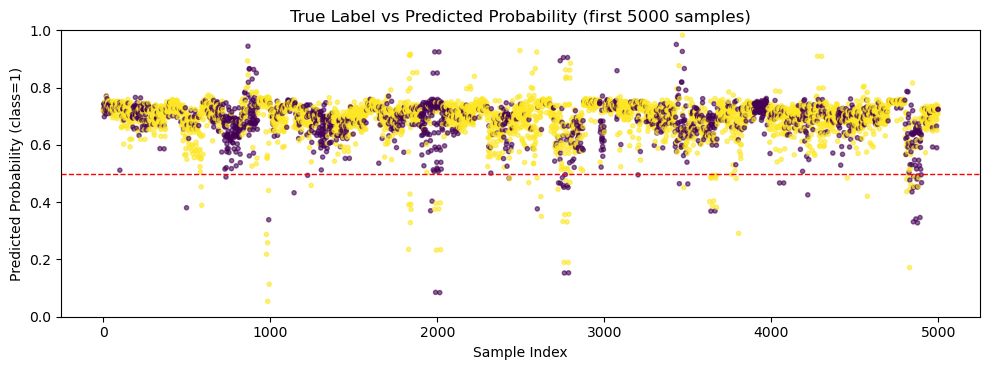


=== Checkpoint n=30227 ===
Accuracy=0.6451, BAcc=0.5069, AUC=0.5663


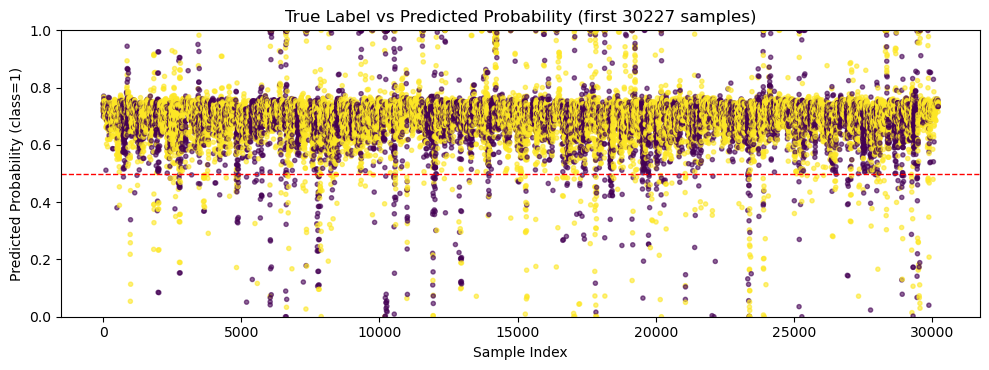


=== Remaining 400 Subject Metrics (Full) ===


,n_samples,n_subjects,accuracy,balanced_accuracy,roc_auc
0,30227,400,0.645119,0.506883,0.566328


,subject,y_true,prob_1,y_pred
0,sub-NDARAA948VFH,1,0.718510,1
1,sub-NDARAA948VFH,1,0.720631,1
2,sub-NDARAA948VFH,1,0.739234,1
3,sub-NDARAA948VFH,1,0.726030,1
4,sub-NDARAA948VFH,0,0.741707,1
5,sub-NDARAA948VFH,0,0.728317,1
6,sub-NDARAA948VFH,0,0.745062,1
7,sub-NDARAA948VFH,0,0.698377,1
8,sub-NDARAA948VFH,0,0.715240,1
9,sub-NDARAA948VFH,0,0.745837,1


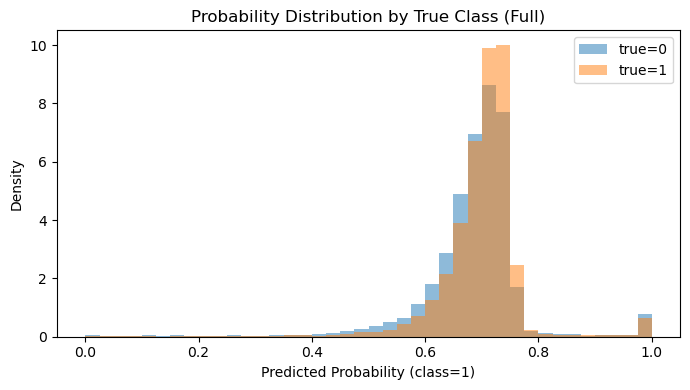

In [1]:
# 3) Evaluate on remaining 400 subjects with progressive checkpoints
from pathlib import Path
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

# Reuse same hash suffix from your cache naming.
HASH_SUFFIX = "6b3c980fa74c"
CACHE_DIR = Path("/mount/NAS-workspace-portal/eeg2025-Vistec/models/data")

X500_path = CACHE_DIR / f"X_ccd_eegnet_n500_p{HASH_SUFFIX}.npy"
y500_path = CACHE_DIR / f"y_ccd_eegnet_n500_p{HASH_SUFFIX}.npy"
g500_path = CACHE_DIR / f"groups_ccd_eegnet_n500_p{HASH_SUFFIX}.npy"

X100_path = CACHE_DIR / f"X_ccd_eegnet_n100_p{HASH_SUFFIX}.npy"
y100_path = CACHE_DIR / f"y_ccd_eegnet_n100_p{HASH_SUFFIX}.npy"
g100_path = CACHE_DIR / f"groups_ccd_eegnet_n100_p{HASH_SUFFIX}.npy"

required = [X500_path, y500_path, g500_path, X100_path, y100_path, g100_path]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing cache files:\n" + "\n".join(missing))

X500 = np.load(X500_path)
y500 = np.load(y500_path).astype(np.int64)
g500 = np.load(g500_path).astype(str)

X100 = np.load(X100_path)
g100 = np.load(g100_path).astype(str)

# Subjects present in n100 cache are treated as known set.
known_subjects = np.unique(g100)
remain_mask = ~np.isin(g500, known_subjects)

X_remain = X500[remain_mask].astype(np.float32, copy=False)
y_remain = y500[remain_mask].astype(np.int64, copy=False)
g_remain = g500[remain_mask]

print("=== Remaining Subjects Evaluation Set ===")
print(f"X500 shape: {X500.shape}")
print(f"X100 shape: {X100.shape}")
print(f"Known subjects (n100): {len(known_subjects)}")
print(f"Remaining unique subjects: {len(np.unique(g_remain))}")
print(f"Remaining samples: {len(X_remain)}")

# Load EEGNet class from train_classify.py
train_file = Path("/mount/NAS-workspace-portal/eeg2025-Vistec/AI_notebook/Deep/EEGNet/train_classify.py")
spec = importlib.util.spec_from_file_location("train_classify", str(train_file))
if spec is None or spec.loader is None:
    raise ImportError(f"Cannot load module from {train_file}")
train_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(train_mod)
EEGNet = train_mod.EEGNet

MODEL_PATH = Path("/mount/NAS-workspace-portal/eeg2025-Vistec/jobs/eegnet_100sub_100ep_lr3e3/model.pt")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH}")

device = torch.device("cpu")
model = EEGNet(
    nb_classes=2,
    Chans=X_remain.shape[2],
    Samples=X_remain.shape[3],
    dropoutRate=0.5,
    kernLength=64,
    F1=8,
    D=2,
    F2=16,
    norm_rate=0.25,
    dropoutType="Dropout",
).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

# Predict progressively and show plots at checkpoints
batch_size = 512
checkpoints = [10, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]
checkpoints = [c for c in checkpoints if c <= len(X_remain)]
if len(X_remain) not in checkpoints:
    checkpoints.append(len(X_remain))
checkpoints = sorted(set(checkpoints))

probs_accum = []
preds_accum = []
next_ckpt_idx = 0

for i in range(0, len(X_remain), batch_size):
    xb = torch.from_numpy(X_remain[i:i + batch_size]).to(device)
    with torch.no_grad():
        logits = model(xb)
        p1 = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        yhat = np.argmax(logits.cpu().numpy(), axis=1)

    probs_accum.extend(p1.tolist())
    preds_accum.extend(yhat.tolist())

    n_done = len(probs_accum)
    while next_ckpt_idx < len(checkpoints) and n_done >= checkpoints[next_ckpt_idx]:
        n_eval = checkpoints[next_ckpt_idx]
        y_true_k = y_remain[:n_eval]
        prob_k = np.asarray(probs_accum[:n_eval])
        pred_k = np.asarray(preds_accum[:n_eval], dtype=np.int64)

        acc_k = accuracy_score(y_true_k, pred_k)
        bacc_k = balanced_accuracy_score(y_true_k, pred_k)
        auc_k = roc_auc_score(y_true_k, prob_k) if len(np.unique(y_true_k)) == 2 else np.nan

        print(f"\n=== Checkpoint n={n_eval} ===")
        print(f"Accuracy={acc_k:.4f}, BAcc={bacc_k:.4f}, AUC={auc_k:.4f}")

        # true vs prob plot for this checkpoint
        plt.figure(figsize=(10, 3.8))
        idx = np.arange(n_eval)
        plt.scatter(idx, prob_k, c=y_true_k, s=9, alpha=0.6)
        plt.axhline(0.5, color="red", linestyle="--", linewidth=1)
        plt.title(f"True Label vs Predicted Probability (first {n_eval} samples)")
        plt.xlabel("Sample Index")
        plt.ylabel("Predicted Probability (class=1)")
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

        next_ckpt_idx += 1

# Final full table and distribution plot
prob_1 = np.asarray(probs_accum)
y_pred = np.asarray(preds_accum, dtype=np.int64)

summary_df = pd.DataFrame(
    [{
        "n_samples": len(y_remain),
        "n_subjects": len(np.unique(g_remain)),
        "accuracy": accuracy_score(y_remain, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_remain, y_pred),
        "roc_auc": roc_auc_score(y_remain, prob_1) if len(np.unique(y_remain)) == 2 else np.nan,
    }]
)
print("\n=== Remaining 400 Subject Metrics (Full) ===")
display(summary_df)

pred_df = pd.DataFrame({
    "subject": g_remain,
    "y_true": y_remain,
    "prob_1": prob_1,
    "y_pred": y_pred,
})

display(pred_df.head(20))

plt.figure(figsize=(7, 4))
for cls in [0, 1]:
    vals = pred_df.loc[pred_df["y_true"] == cls, "prob_1"].values
    if len(vals) > 0:
        plt.hist(vals, bins=40, alpha=0.5, density=True, label=f"true={cls}")
plt.title("Probability Distribution by True Class (Full)")
plt.xlabel("Predicted Probability (class=1)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()